# Mediapipe (Pose Landmarker Lite) + Yolo_v8 (object detection)

# 1. Importazione e installazione delle dipendenze

In [2]:
!pip install mediapipe opencv-python numpy psutil pandas openpyxl torch ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 1.3 MB/s  0:00:49 eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 1.4 MB/s  0:00:00m 1.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 1.9 MB/s  0:00:002.3 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 3.9 MB/s  0:00:004.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 3.1 MB/s  0:00:003.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 4.9 MB/s  0:00:08 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 3.1 MB/s  0:00:07a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 2.5 MB/s  0:00:022.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 3.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 3.3 MB/s  0:00:003.2 MB/s eta 0:00:01
  Attempting uninstall: setuptools;237m╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import mediapipe as mp
import cv2
import os
import psutil
import time
import glob
import numpy as np
import torch #pytorch: sviluppato da Meta AI 
import pandas as pd 
import platform
import matplotlib.pyplot as plt 
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.framework.formats import landmark_pb2
from ultralytics import YOLO # serve per vedere oggetti (persone, auto, telefoni) con  precisione e velocità

In [2]:
print(f"MediaPipe version: {mp.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device YOLO: {'MPS (GPU Apple)' if torch.backends.mps.is_available() else 'CPU'}")
print(f"CPU: {platform.processor()}")
print(f"RAM totale: {psutil.virtual_memory().total / 1e9:.1f} GB")

MediaPipe version: 0.10.14
PyTorch version: 2.11.0
Device YOLO: MPS (GPU Apple)
CPU: arm
RAM totale: 8.6 GB


# 2. Configurazione dei due modelli

In [3]:
pose_model = "pose_landmarker_lite.task"  # carichiamo il modello pre-addestrato di mediapipe pose landmarker

# Open Cv usa formato BGR, usiamo il magenta
DEFAULT_COLOR = (255, 0, 255)

In [4]:
mp_drawing       = mp.solutions.drawing_utils #cerca le utility di disegno di MediaPipe
mp_pose_sol      = mp.solutions.pose #Contiene le definizioni del corpo umano 

# Pytorch usa il MPS (Metal Performance Shaders) ovvero è il framework di Apple che permette a Pytorch di accedere alla potenza di calcolo della GPU
device = 'mps' if torch.backends.mps.is_available() else 'cpu'

# 3. Resize automatico
- Facciamo in modo che sia il modello stesso a stabilire la dimensione del frame necessaria, determinando un fattore di scala a seconda del limite dimensionale stabilito (**`max_w=720`**) 

In [5]:
def get_display_size(frame, max_w=720):
    h, w = frame.shape[:2] #restituisce la tupla tipo (altezza, larghezza, canali colore), con [:2] prendono altezza e larghezza
    if w > max_w: # Controllo della larghezza massima
        scale = max_w / w #Calcolo del fattore di scala: se la nostra immagine è larga 1440px ma il nostro limite è 720ps farà 720/1440= 0.5
        return int(w * scale), int(h * scale)
    return w, h

# 4. Pannello di controllo Mediapipe

- Definiamo una funzione per costruire le opzioni di configuazione della componente MediaPipe. Ritorniamo l'oggetto ottenente **tutte** le configurazioni del PoseLandmarker:
- `base_options`: Specifichiamo le opzioni di base, come il percorso del file del modello (.task)
- `running_mode`: Impostiamo la modalità di esecuzione: IMAGE significa che elaborerà singole foto (non video stream)
- `num_poses`:  Indica il numero massimo di persone che il modello deve cercare di rilevare
- `min_pose_detection_confidence`: Soglia minima di confidenza (30%) affinché il rilevamento iniziale della posa sia considerato valido
- `min_pose_presence_confidence`: Soglia minima affinché il modello confermi che una posa è effettivamente presente nell'immagine
- `min_tracking_confidence`: Soglia minima per il tracking della posa (usata principalmente in modalità video per "seguire" i punti)
- `output_segmentation_masks`: **Settato a false**. Se impostato su True, genererebbe una maschera per separare la persona dallo sfondo (segmentazione)

In [6]:
def build_mp_options(num_poses=2):
    return vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=pose_model),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=num_poses,
        min_pose_detection_confidence=0.3,
        min_pose_presence_confidence=0.3,
        min_tracking_confidence=0.3,
        output_segmentation_masks=False,
    )



# 5. Rendering
Definiamo la funzione per disegnare lo scheletro con parametri di offset (spostamento) e scala:  
- `h, w` : Estraiamo l'altezza (h) e la larghezza (w) del canvas (l'immagine di destinazione).
- `dot`: Definiamo lo stile dei punti chiave: colore predefinito, spessore 3 e raggio 5
- `line`: Definiamo lo stile dei collegamenti tra i punti: colore predefinito e spessore 4
- `proto`: Creiamo un oggetto lista di landmark nel formato richiesto da MediaPipe (Protobuf)
-  `abs_x`: Applichiamo una scala e offset alla coordinata X, poi la normalizziamo dividendo per la larghezza w
-  `abs_y`: Applichiamo una scala e offset alla coordinata Y, poi la normalizziamo dividendo per l'altezza h
-  `proto.landmark.append` : Aggiungiamo il nuovo punto trasformato alla lista proto, mantenendo la coordinata Z originale
-  `mp_drawing`: diesgniamo effettivamente i punti e le connessioni sul canvas usando le specifiche definite sopra

In [7]:
def draw_skeleton_on_canvas(canvas, landmarks, x_off, y_off, scale_x, scale_y):
    h, w = canvas.shape[:2]
    dot  = mp.solutions.drawing_utils.DrawingSpec(color=DEFAULT_COLOR, thickness=3, circle_radius=5)
    line = mp.solutions.drawing_utils.DrawingSpec(color=DEFAULT_COLOR, thickness=4)
    proto = landmark_pb2.NormalizedLandmarkList()
 
    for lm in landmarks:
        abs_x = (lm.x * scale_x + x_off) / w
        abs_y = (lm.y * scale_y + y_off) / h
        proto.landmark.append(landmark_pb2.NormalizedLandmark(x=abs_x, y=abs_y, z=lm.z))
    mp_drawing.draw_landmarks(canvas, proto, mp_pose_sol.POSE_CONNECTIONS, dot, line)


# 6. Pipeline

La pipeline è la sequenza di operazioni che ogni frame attraversa, dall'input grezzo fino al salvataggio delle metriche.
Ogni stage è una funzione separata il Main le chiama in ordine.

> **Differenza rispetto agli altri modelli:** In questo caso abbiamo una pipeline **a due livelli**.
> YOLO si occupa di rilevare le bounding box delle persone nel frame intero.
> MediaPipe lavora su ogni singolo **crop** ritagliato da YOLO, non sul frame intero.

##  7. Pre-processing
Prepariamo i 2 canvas su cui lavorare:
- `colored`: è la copia del frame originale su cui disegnare skeleton e bounding box
- `black`: è la canvas nera delle stesse dimensioni per il rendering scheletro isolato

In [8]:
def pre_processing(frame):
    colored = frame.copy()
    black   = np.zeros_like(frame)
    return colored, black

## 8. YOLO Detection

Rileviamo le persone nel frame intero con YOLOv8 e restituisce bounding box + ID persistenti: 
- `h, w`: Ottiene altezza (h) e larghezza (w) del frame corrente
- Considera al massimo le prime 6 persone rilevate
- Aggiunge un margine del 10% attorno ad ogni box per non tagliare braccia/gambe
- Per `yolo_results`:
> - `persist=True`: mantiene gli ID di tracking coerenti tra frame consecutivi
> - `classes=[0]`: rileva solo la classe 0 (persone nel dataset COCO, su cui YOLO è pre-addestrato)
> - `imgsz=480`: ridimensiona l'input a 480px per bilanciare velocità e precisione
> - `verbose=False`: sopprime l'output di log a console
> - `device=device`: specifica CPU/GPU su cui eseguire l'inferenza

In [9]:
def yolo_detection(yolo_model, frame, device):
    h, w = frame.shape[:2]

    yolo_results = yolo_model.track(frame, persist=True, verbose=False, classes=[0], imgsz=480, device=device)

    # Controlliamo se YOLO ha rilevato e assegnato degli ID
    if yolo_results[0].boxes.id is None:
        return [], [], yolo_results

    boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
    ids   = yolo_results[0].boxes.id.cpu().numpy().astype(int)


    boxes = boxes[:6]
    ids   = ids[:6]

    padded_boxes = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        margin_x = int((x2 - x1) * 0.1)
        margin_y = int((y2 - y1) * 0.1)
        x1c = max(0, x1 - margin_x)
        y1c = max(0, y1 - margin_y)
        x2c = min(w, x2 + margin_x)
        y2c = min(h, y2 + margin_y)
        padded_boxes.append((x1, y1, x2, y2, x1c, y1c, x2c, y2c))

    return padded_boxes, ids, yolo_results


## 9. MediaPipe Pose Estimation (per crop)
Per ogni persona rilevata da YOLO, ritagliamo il frame sul box e stimiamo la posa con MediaPipe.
- Convertiamo il crop in `RGB` e lo trasforma nel formato `mp.Image`
- Chiamiamo `mp_lm.detect()` sul singolo crop
- Disegniamo lo skeleton su `colored` e `black` usando `draw_skeleton_on_canvas` che riposiziona i landmark con offset e scala
- Disegniamo il bounding box YOLO e l'ID persona su `colored`

In [10]:
def mediapipe_pose_estimation(mp_lm, frame, colored, black, padded_boxes, ids):
    all_keypoints = []  # lista per raccogliere i keypoint di ogni persona

    for i, box in enumerate(padded_boxes):
        x1, y1, x2, y2, x1c, y1c, x2c, y2c = box
        obj_id = ids[i]  # Recupera l'ID reale della persona

        # Ritagliamo l'immagine (crop) sulla singola persona rilevata
        crop = frame[y1c:y2c, x1c:x2c]

        # Se il ritaglio è vuoto, passa alla prossima persona
        if crop.size == 0:
            continue

        # Prepariamo l'immagine ritagliata per MediaPipe (conversione BGR -> RGB)
        crop_h, crop_w = crop.shape[:2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        # Creiamo l'oggetto immagine specifico di MediaPipe
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=crop_rgb)
        # Eseguiamo il rilevamento dei punti dello scheletro solo sul ritaglio
        result = mp_lm.detect(mp_img)

        # Se MediaPipe ha trovato uno scheletro
        if result.pose_landmarks:
    
            draw_skeleton_on_canvas(colored, result.pose_landmarks[0], x_off=x1c, y_off=y1c, scale_x=crop_w, scale_y=crop_h)
            draw_skeleton_on_canvas(black,   result.pose_landmarks[0], x_off=x1c, y_off=y1c, scale_x=crop_w, scale_y=crop_h)
           
            # Salva le coordinate (x, y) dei 33 landmark di questa persona
            coords = np.array([[lm.x * crop_w + x1c, lm.y * crop_h + y1c]
                                for lm in result.pose_landmarks[0]])
            all_keypoints.append(coords)  # shape: (33, 2)


        # Disegniamo il rettangolo di YOLO (Bounding Box) attorno alla persona
        cv2.rectangle(colored, (x1, y1), (x2, y2), DEFAULT_COLOR, 1)
        # Aggiungiamo un'etichetta con l'ID persistente della persona
        cv2.putText(colored, f"ID {obj_id}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, DEFAULT_COLOR, 1)

    return colored, black, all_keypoints


## 10. Post-processing
Calcoliamo le metriche di qualità del rilevamento sull'intero frame:
- **`n_people`**: numero di persone rilevate da YOLO nel frame
- **`conf_mean`**: confidenza media YOLO sulle detection → proxy dell'accuratezza
- **`jitter`**: variazione del numero di persone rilevate rispetto al frame precedente → proxy della stabilità del tracking

In [11]:
def post_processing(yolo_results_raw, all_keypoints, prev_keypoints=None, prev_n_people=None):
    if yolo_results_raw[0].boxes.id is not None:
        n_people  = len(yolo_results_raw[0].boxes.xyxy)
        # Confidenza media YOLO sulle detection (proxy accuratezza)
        conf_mean = round(float(yolo_results_raw[0].boxes.conf.cpu().numpy().mean()), 4)
    else:
        n_people  = 0
        conf_mean = 0.0
    
    # Jitter persone: variazione del numero di persone rilevate
    jitter_people = abs(n_people - prev_n_people) if prev_n_people is not None else 0

    # Jitter keypoints: spostamento medio delle coordinate
    if prev_keypoints is not None and len(all_keypoints) > 0 and len(prev_keypoints) > 0:
        n = min(len(all_keypoints), len(prev_keypoints))
        jitter_kp = round(float(np.mean([
            np.abs(all_keypoints[i] - prev_keypoints[i]).mean()
            for i in range(n)])), 4)
    else:
        jitter_kp = 0.0

    return {
        'n_people':  n_people,
        'conf_mean': conf_mean,
        'jitter_people': jitter_people,
        'jitter_kp' : jitter_kp,
    }

## 11. Rendering finale
Ridimensioniamo le canvas per il display, affianca `colored` e `black` con `np.hstack`, e sovrapponiamo le metriche con testo scalato proporzionalmente alla risoluzione.

In [12]:
def rendering(colored, black, fps, cpu_usage, ram_usage, boxes):
    # otteniamo le dimensioni del display
    dw, dh     = get_display_size(colored)
    font_scale = dw / 640  # utilizziamo font_scale con 640 pixel come base di riferimento (larghezza standard di una webcam VGA)
    colored    = cv2.resize(colored, (dw, dh))
    black      = cv2.resize(black,   (dw, dh))
    combined   = np.hstack((colored, black))

    cv2.putText(combined, f"CPU: {cpu_usage}%",          (10, int(30*font_scale)),  cv2.FONT_HERSHEY_SIMPLEX, font_scale, (  0,255,  0), 2)
    cv2.putText(combined, f"RAM: {ram_usage:.1f} MB",    (10, int(60*font_scale)),  cv2.FONT_HERSHEY_SIMPLEX, font_scale, (  0,255,  0), 2)
    cv2.putText(combined, f"FPS: {int(fps)}",            (10, int(90*font_scale)),  cv2.FONT_HERSHEY_SIMPLEX, font_scale, (  0,255,  0), 2)
    cv2.putText(combined, f"Persone: {len(boxes)}",      (10, int(120*font_scale)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255,180,  0), 2)

    return combined

## 12. Raccolta metriche
Raccoglie tutte le metriche del frame in un dizionario. 
Ogni chiamata produce una riga dell'Excel finale.

In [13]:
def collect_metrics(video_name, run, frame_count, fps, cpu_usage, ram_usage, post_data):
    return {
        "Video name":  video_name,
        "Execution":   run + 1,
        "Frame N":     frame_count,
        "CPU (%)":     cpu_usage,
        "RAM (MB)":    round(ram_usage, 2),
        "FPS":         round(fps, 2),
        "Confidence":  post_data['conf_mean'],
        "People det":  post_data['n_people'],
        "Jitter people": post_data['jitter_people'], 
        "Jitter kp":     post_data['jitter_kp'],  
    }

# 13. Main (fase di detection)

In [14]:
video_folder = "/Users/rebeccaspigacortes/Desktop/data_set_multipose/"
video_paths  = sorted(glob.glob(video_folder + "/*.mp4"))
process          = psutil.Process(os.getpid())

yolo_model = YOLO("yolov8n.pt") # Carichiamo il modello YOLOv8 Nano (il più leggero) per il rilevamento degli oggetti
mp_opts    = build_mp_options(num_poses=2) # Generiamo le impostazioni di MediaPipe usando la funzione definita in precedenza

project_data = []

# Inizializza l'istanza di MediaPipe PoseLandmarker
with vision.PoseLandmarker.create_from_options(mp_opts) as mp_lm:

    for video_path in video_paths:
        video_name = os.path.basename(video_path)
        print(f"\n{'='*40}")
        print(f"Processo: {video_name}")

        
        for run in range(2):
            print(f"I'm playing: {video_name} | Execution: {run + 1}/2")

            cap          = cv2.VideoCapture(video_path)
            frame_count  = 0
            prev_time    = 0
            prev_n_people = None  # per il calcolo del jitter per le persone
            prev_keypoints = None # per il calcolo dei jitter dei keypoints

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                frame_count += 1

                # FPS
                curr_time = time.perf_counter()
                fps = 1 / (curr_time - prev_time) if prev_time != 0 else 0
                prev_time = curr_time

                # CPU e RAM 
                cpu_usage = psutil.cpu_percent()
                ram_usage = process.memory_info().rss / (1024 * 1024)
                
                # Esegue YOLO una sola volta: rileva le persone, calcola i bounding box con padding
                # e recupera l'oggetto raw necessario per le metriche di post-processing

                colored, black = pre_processing(frame)                                    
                padded_boxes, ids, yolo_results_raw = yolo_detection(yolo_model, frame, device)             
                colored, black, all_keypoints = mediapipe_pose_estimation(mp_lm, frame,colored, black, padded_boxes, ids)
                post_data = post_processing(yolo_results_raw, all_keypoints, prev_keypoints, prev_n_people)
                combined = rendering(colored, black, fps, cpu_usage, ram_usage, padded_boxes)
                project_data.append(collect_metrics(video_name, run, frame_count, fps, cpu_usage, ram_usage, post_data))

                prev_n_people  = post_data['n_people']
                prev_keypoints = all_keypoints

                # print per vedere i risultati nella console
                print(f"CPU: {cpu_usage}% | RAM: {ram_usage:.2f}MB | FPS: {fps:.1f}")
                cv2.imshow("YOLO + MediaPipe 3D Multipose", combined)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break

            cap.release()
            cv2.destroyAllWindows()

I0000 00:00:1776620826.992346 18278018 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776620827.065979 18281518 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776620827.076450 18281522 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



Processo: 01-volleyball.mp4
I'm playing: 01-volleyball.mp4 | Execution: 1/2
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/1.5 MB 1.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━ 1.0/1.5 MB 2.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━ 1.0/1.5 MB 2.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 1.3/1.5 MB 1.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 1.3/1.5 MB 1.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 1.3/1.5 MB 1.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 878.0 kB/s  0:00:01

requirements: AutoUpdate success ✅ 3.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



/Users/rebeccaspigacortes/miniconda3/envs/mediapipe_yolo/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


CPU: 54.1% | RAM: 486.30MB | FPS: 0.0
CPU: 17.8% | RAM: 741.98MB | FPS: 0.1
CPU: 49.4% | RAM: 764.58MB | FPS: 8.8
CPU: 60.3% | RAM: 764.97MB | FPS: 11.1
CPU: 48.4% | RAM: 757.47MB | FPS: 11.7
CPU: 32.0% | RAM: 759.77MB | FPS: 8.3
CPU: 22.6% | RAM: 766.62MB | FPS: 12.3
CPU: 0.0% | RAM: 760.12MB | FPS: 12.6
CPU: 0.0% | RAM: 750.81MB | FPS: 11.9
CPU: 0.0% | RAM: 751.48MB | FPS: 12.9
CPU: 0.0% | RAM: 757.34MB | FPS: 12.6
CPU: 0.0% | RAM: 757.47MB | FPS: 12.6
CPU: 0.0% | RAM: 758.00MB | FPS: 12.8
CPU: 18.2% | RAM: 762.14MB | FPS: 11.2
CPU: 23.7% | RAM: 765.75MB | FPS: 10.3
CPU: 12.2% | RAM: 772.59MB | FPS: 10.5
CPU: 15.2% | RAM: 777.33MB | FPS: 10.4
CPU: 21.3% | RAM: 780.86MB | FPS: 10.7
CPU: 10.2% | RAM: 780.58MB | FPS: 13.0
CPU: 14.8% | RAM: 787.16MB | FPS: 10.4
CPU: 0.0% | RAM: 787.33MB | FPS: 12.4
CPU: 0.0% | RAM: 786.58MB | FPS: 10.1
CPU: 0.0% | RAM: 786.80MB | FPS: 13.3
CPU: 0.0% | RAM: 792.14MB | FPS: 12.5
CPU: 0.0% | RAM: 796.22MB | FPS: 10.4
CPU: 14.0% | RAM: 796.50MB | FPS: 12.5
C

# 14. Export dati → Excel
Salva `project_data` in un file `.xlsx`.

In [15]:
df = pd.DataFrame(project_data)

excel_name = f"results_mediapipe_yolo_{platform.node()}.xlsx"
df.to_excel(excel_name, index=False)

print(f"Salvato: {excel_name}")
print(df.describe().round(3))


Salvato: results_mediapipe_yolo_MACBOOKAIR-2547.station.xlsx
       Execution    Frame N    CPU (%)   RAM (MB)        FPS  Confidence  \
count    15730.0  15730.000  15730.000  15730.000  15730.000   15730.000   
mean         1.5    207.766     14.214    756.783      8.376       0.756   
std          0.5    143.749     11.701     97.965      2.915       0.149   
min          1.0      1.000      0.000    352.110      0.000       0.000   
25%          1.0     94.000      0.000    705.300      5.932       0.669   
50%          1.5    188.000     16.700    756.330      7.880       0.812   
75%          2.0    282.000     21.000    823.338     10.400       0.866   
max          2.0    604.000     79.900   1077.500     20.050       0.947   

       People det  Jitter people  Jitter kp  
count   15730.000      15730.000  15730.000  
mean        3.683          0.230     31.089  
std         3.357          0.645     69.603  
min         0.000          0.000      0.000  
25%         2.000       

# 15. Analisi stabilità tra i due run
Confronta le metriche medie del run 1 e del run 2.
Un modello stabile produce valori simili in entrambe le esecuzioni sullo stesso video.

In [16]:
summary = df.groupby("Execution")[["FPS", "CPU (%)", "RAM (MB)",
                                    "Confidence", "Jitter people", "Jitter kp"]].mean().round(3)
print(summary)
print("\nDelta run1 vs run2:")
print((summary.loc[2] - summary.loc[1]).round(3))

             FPS  CPU (%)  RAM (MB)  Confidence  Jitter people  Jitter kp
Execution                                                                
1          8.394   14.336   770.185       0.756          0.231     31.130
2          8.357   14.093   743.381       0.757          0.230     31.048

Delta run1 vs run2:
FPS              -0.037
CPU (%)          -0.243
RAM (MB)        -26.804
Confidence        0.001
Jitter people    -0.001
Jitter kp        -0.082
dtype: float64


# 16. Cella di RIEPILOGO

In [17]:
print(f"{'='*40}")
print(f"RIEPILOGO ESECUZIONE")
print(f"{'='*40}")
print(f"Video processati:        {df['Video name'].nunique()}")
print(f"Frame totali analizzati: {len(df)}")
print(f"Esecuzioni per video:    {df['Execution'].max()}")
print(f"Frame totali (run x2):   {len(df)}")
print(f"\nVideo inclusi nel test:")
for v in sorted(df['Video name'].unique()):
    n_frames = len(df[df['Video name'] == v]) // int(df['Execution'].max())
    print(f"  - {v}  ({n_frames} frame/run)")

RIEPILOGO ESECUZIONE
Video processati:        21
Frame totali analizzati: 15730
Esecuzioni per video:    2
Frame totali (run x2):   15730

Video inclusi nel test:
  - 01-volleyball.mp4  (601 frame/run)
  - 02-beach-volley.mp4  (604 frame/run)
  - 03-running2.mp4  (302 frame/run)
  - 04-three-guys.mp4  (301 frame/run)
  - 05-yoga.mp4  (290 frame/run)
  - 06-partner-yoga.mp4  (278 frame/run)
  - 07-fit-guys.mp4  (574 frame/run)
  - 08-kpop-cover2.mp4  (572 frame/run)
  - 09-crowd-people.mp4  (300 frame/run)
  - 10-calisthenics.mp4  (600 frame/run)
  - 12-ciclist.mp4  (334 frame/run)
  - 13-basketballplay.mp4  (301 frame/run)
  - 14-dancing-ladies.mp4  (301 frame/run)
  - 15-equitation.mp4  (353 frame/run)
  - 16-kpop-cover.mp4  (301 frame/run)
  - 17-skill.mp4  (304 frame/run)
  - 18-roller.mp4  (302 frame/run)
  - 19-football-guy.mp4  (290 frame/run)
  - 20-gym-girl.mp4  (276 frame/run)
  - 20-multipose5.mp4  (322 frame/run)
  - 21-extra.mp4  (359 frame/run)


# 17. Grafici

Creiamo due grafici: 
- **metrics_mean_overview.png**
  > mostrerà la media per video di FPS, CPU, RAM, Confidence, People det e
    Jitter, attraverso un grafico a barre per ogni metrica. Sarà utile per
    confrontare le prestazioni del modello sui diversi video.

- **run_comparison.png**
  > confronterà i valori medi del Run 1 e Run 2 per ogni metrica, in un              grafico a barre. Sarà utile per verificare la stabilità del modello tra le       due esecuzioni 

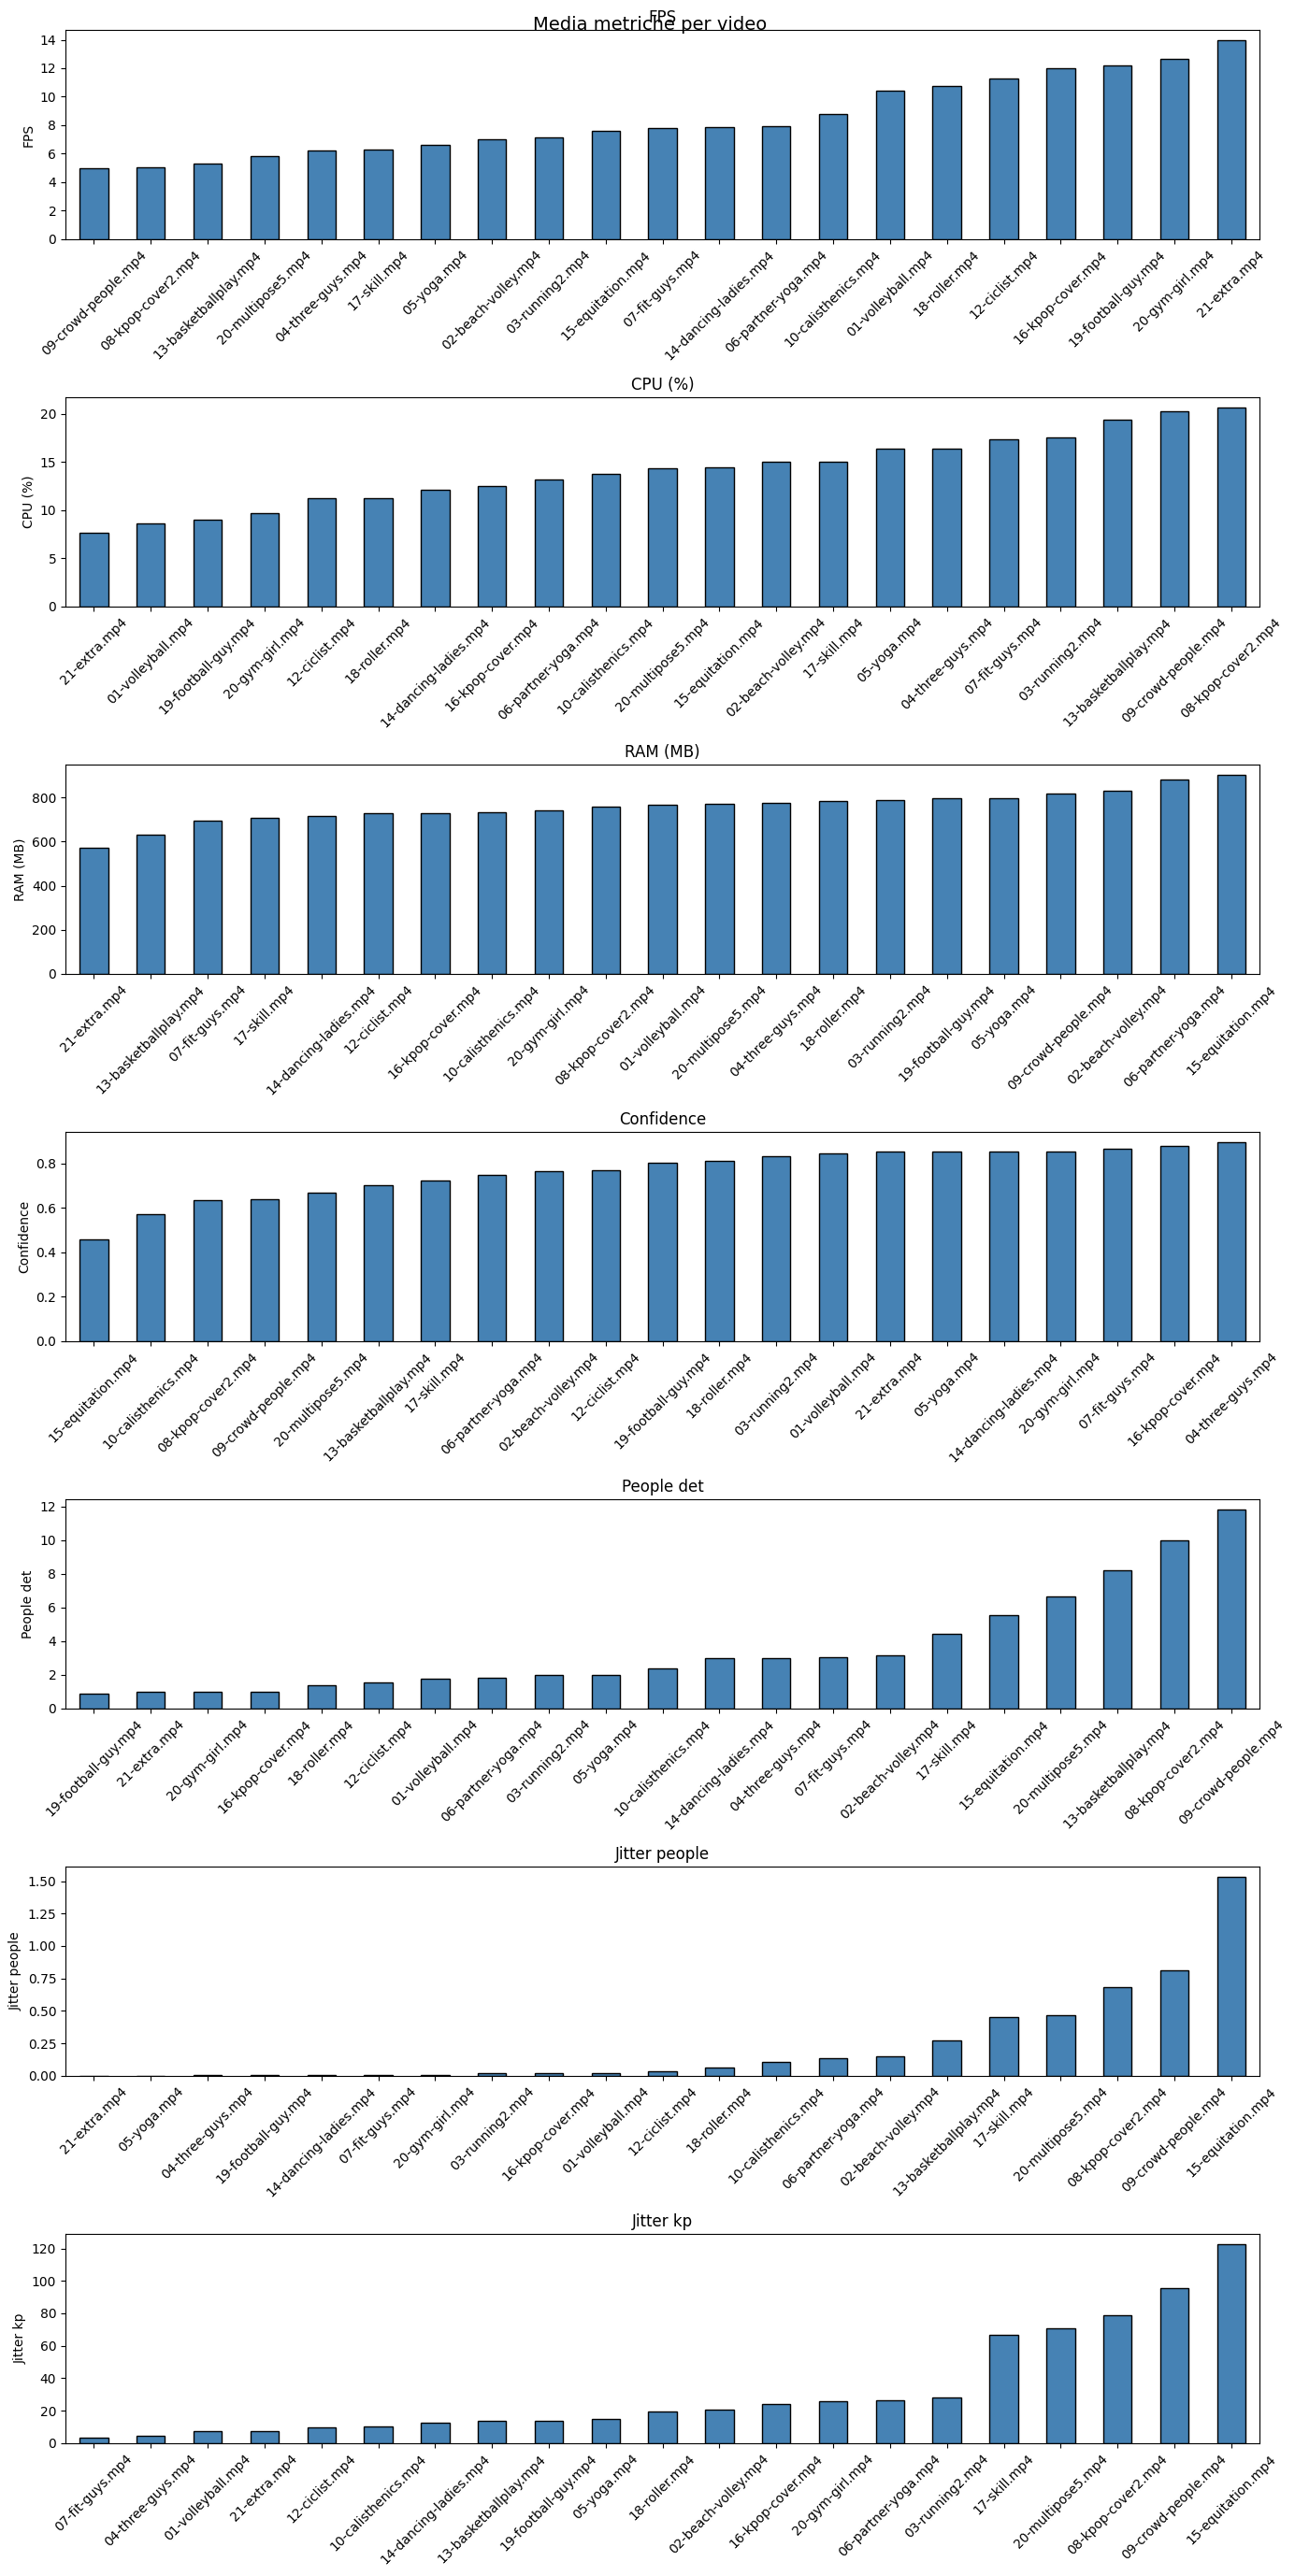

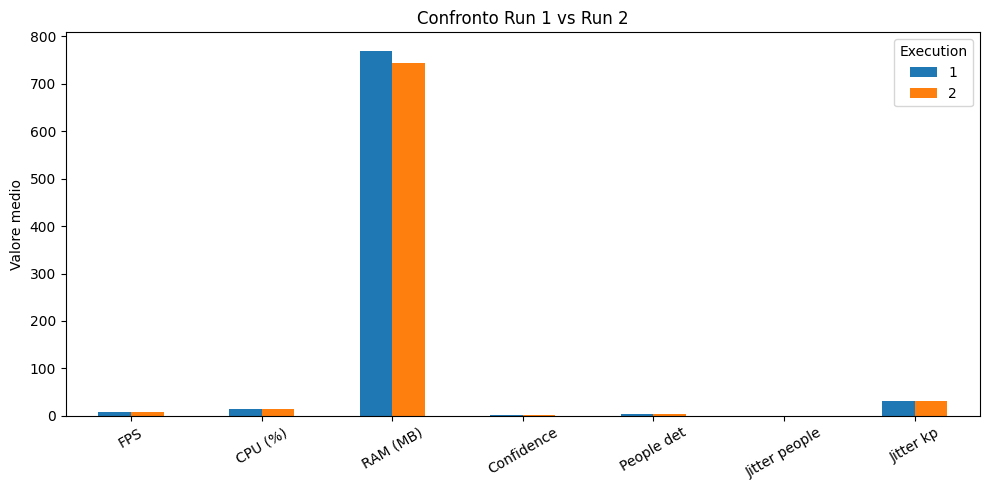

In [18]:
metrics = ['FPS', 'CPU (%)', 'RAM (MB)', 'Confidence', 'People det', 'Jitter people', 'Jitter kp']

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)))
fig.suptitle("Media metriche per video", fontsize=14)

for ax, metric in zip(axes, metrics):
    means = df.groupby('Video name')[metric].mean().sort_values()
    means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("metrics_mean_overview.png", dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: confronto Run 1 vs Run 2
summary = df.groupby("Execution")[metrics].mean().round(3)

summary.T.plot(kind="bar", figsize=(10, 5), title="Confronto Run 1 vs Run 2")
plt.ylabel("Valore medio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("run_comparison.png", dpi=150)
plt.show()